EXERCICE 1 : L'arbre de décision en tarification — Comprendre le .fit()
========================================================================
Objectif : Construire un arbre de décision pour la fréquence sinistre,
visualiser sa structure, et comprendre comment il segmente le risque.

Ce que vous allez apprendre :
- Construire un arbre de décision avec le critère Poisson
- Visualiser et interpréter l'arbre (splits, feuilles, prédictions)
- Observer l'impact de la profondeur sur le biais-variance
- Comparer avec le GLM Poisson vu dans M03_F01

Pré-requis : M03_F01 (pipeline, cross-validation, Poisson deviance)
Temps estimé : 15 minutes

In [46]:
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeRegressor, plot_tree, export_text
from sklearn.linear_model import PoissonRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_poisson_deviance
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

## 1. CHARGEMENT DES DONNÉES (même dataset que M03_F01)

In [51]:
# =============================================================
print("=" * 60)
print("EXERCICE 1 : L'arbre de décision en tarification")
print("=" * 60)

df = pd.read_csv("../M03_F01_Machine_Learning_Fondamentaux/freMTPL2freq.csv")
print(f"Dataset chargé : {df.shape[0]} lignes, {df.shape[1]} colonnes")

features = ['DrivAge', 'BonusMalus', 'VehAge', 'Density']
X = df[features].astype(float)
y = df['ClaimNb'].astype(float)
exposure = df['Exposure'].astype(float)

X_train, X_test, y_train, y_test, exp_train, exp_test = train_test_split(
    X, y, exposure, test_size=0.3, random_state=42
)
print(X_train)
# # Standardisation
# scaler = StandardScaler()
# X_train = scaler.fit_transform(X_train)  # Fit sur train
# X_test = scaler.transform(X_test)

print(f"Train : {X_train.shape[0]} | Test : {X_test.shape[0]}")

EXERCICE 1 : L'arbre de décision en tarification
Dataset chargé : 678013 lignes, 12 colonnes
        DrivAge  BonusMalus  VehAge  Density
566452     33.0        60.0    14.0     71.0
160831     54.0        50.0     6.0    821.0
626694     21.0        90.0     0.0   2399.0
218427     45.0        50.0     9.0     10.0
51959      52.0        54.0     0.0    415.0
...         ...         ...     ...      ...
259178     57.0        85.0     6.0    879.0
365838     46.0        56.0    10.0   1609.0
131932     35.0        50.0     8.0   3744.0
671155     32.0        54.0     1.0   6485.0
121958     56.0        50.0     2.0    182.0

[474609 rows x 4 columns]
Train : 474609 | Test : 203404


In [52]:
# =============================================================
# 2. ARBRE DE DÉCISION AVEC CRITÈRE POISSON
# =============================================================
# Le critère 'poisson' est adapté aux comptages (fréquence sinistre)
# C'est l'équivalent du critère de déviance du GLM Poisson

print("\n" + "=" * 60)
print("PARTIE 1 : Construction d'un arbre de décision (critère Poisson)")
print("=" * 60)

# TODO : Construire un arbre de profondeur 4 avec le critère Poisson
# Indice : DecisionTreeRegressor(criterion='poisson', max_depth=4)
# Attention : on modélise la fréquence = ClaimNb / Exposure

tree = DecisionTreeRegressor(criterion='poisson', max_depth=4, random_state=1)

# TODO : Fitter le modèle sur la fréquence (y/exposure), pondéré par l'exposure
freq_train = y_train / exp_train
freq_test = y_test / exp_test

tree.fit(X_train, freq_train, sample_weight=exp_train)

# TODO : Prédire sur le test set (le modèle prédit la fréquence directement)
freq_pred_tree = tree.predict(X_test)
freq_pred_tree = np.clip(freq_pred_tree, 1e-6, None)

dev_tree = mean_poisson_deviance(freq_test, freq_pred_tree, sample_weight=exp_test)
print(f"Poisson Deviance (arbre depth=4) : {dev_tree:.6f}")



PARTIE 1 : Construction d'un arbre de décision (critère Poisson)
Poisson Deviance (arbre depth=4) : 0.594118



PARTIE 2 : Visualisation
--------------------------------------------------

Structure de l'arbre (texte) :
|--- VehAge <= 0.50
|   |--- BonusMalus <= 89.00
|   |   |--- Density <= 486.50
|   |   |   |--- Density <= 5.50
|   |   |   |   |--- value: [1.22]
|   |   |   |--- Density >  5.50
|   |   |   |   |--- value: [0.26]
|   |   |--- Density >  486.50
|   |   |   |--- DrivAge <= 49.50
|   |   |   |   |--- value: [0.36]
|   |   |   |--- DrivAge >  49.50
|   |   |   |   |--- value: [0.30]
|   |--- BonusMalus >  89.00
|   |   |--- DrivAge <= 42.50
|   |   |   |--- Density <= 593.00
|   |   |   |   |--- value: [0.45]
|   |   |   |--- Density >  593.00
|   |   |   |   |--- value: [0.61]
|   |   |--- DrivAge >  42.50
|   |   |   |--- DrivAge <= 53.50
|   |   |   |   |--- value: [0.29]
|   |   |   |--- DrivAge >  53.50
|   |   |   |   |--- value: [0.51]
|--- VehAge >  0.50
|   |--- BonusMalus <= 57.50
|   |   |--- VehAge <= 12.50
|   |   |   |--- DrivAge <= 39.50
|   |   |   |   |--- value:

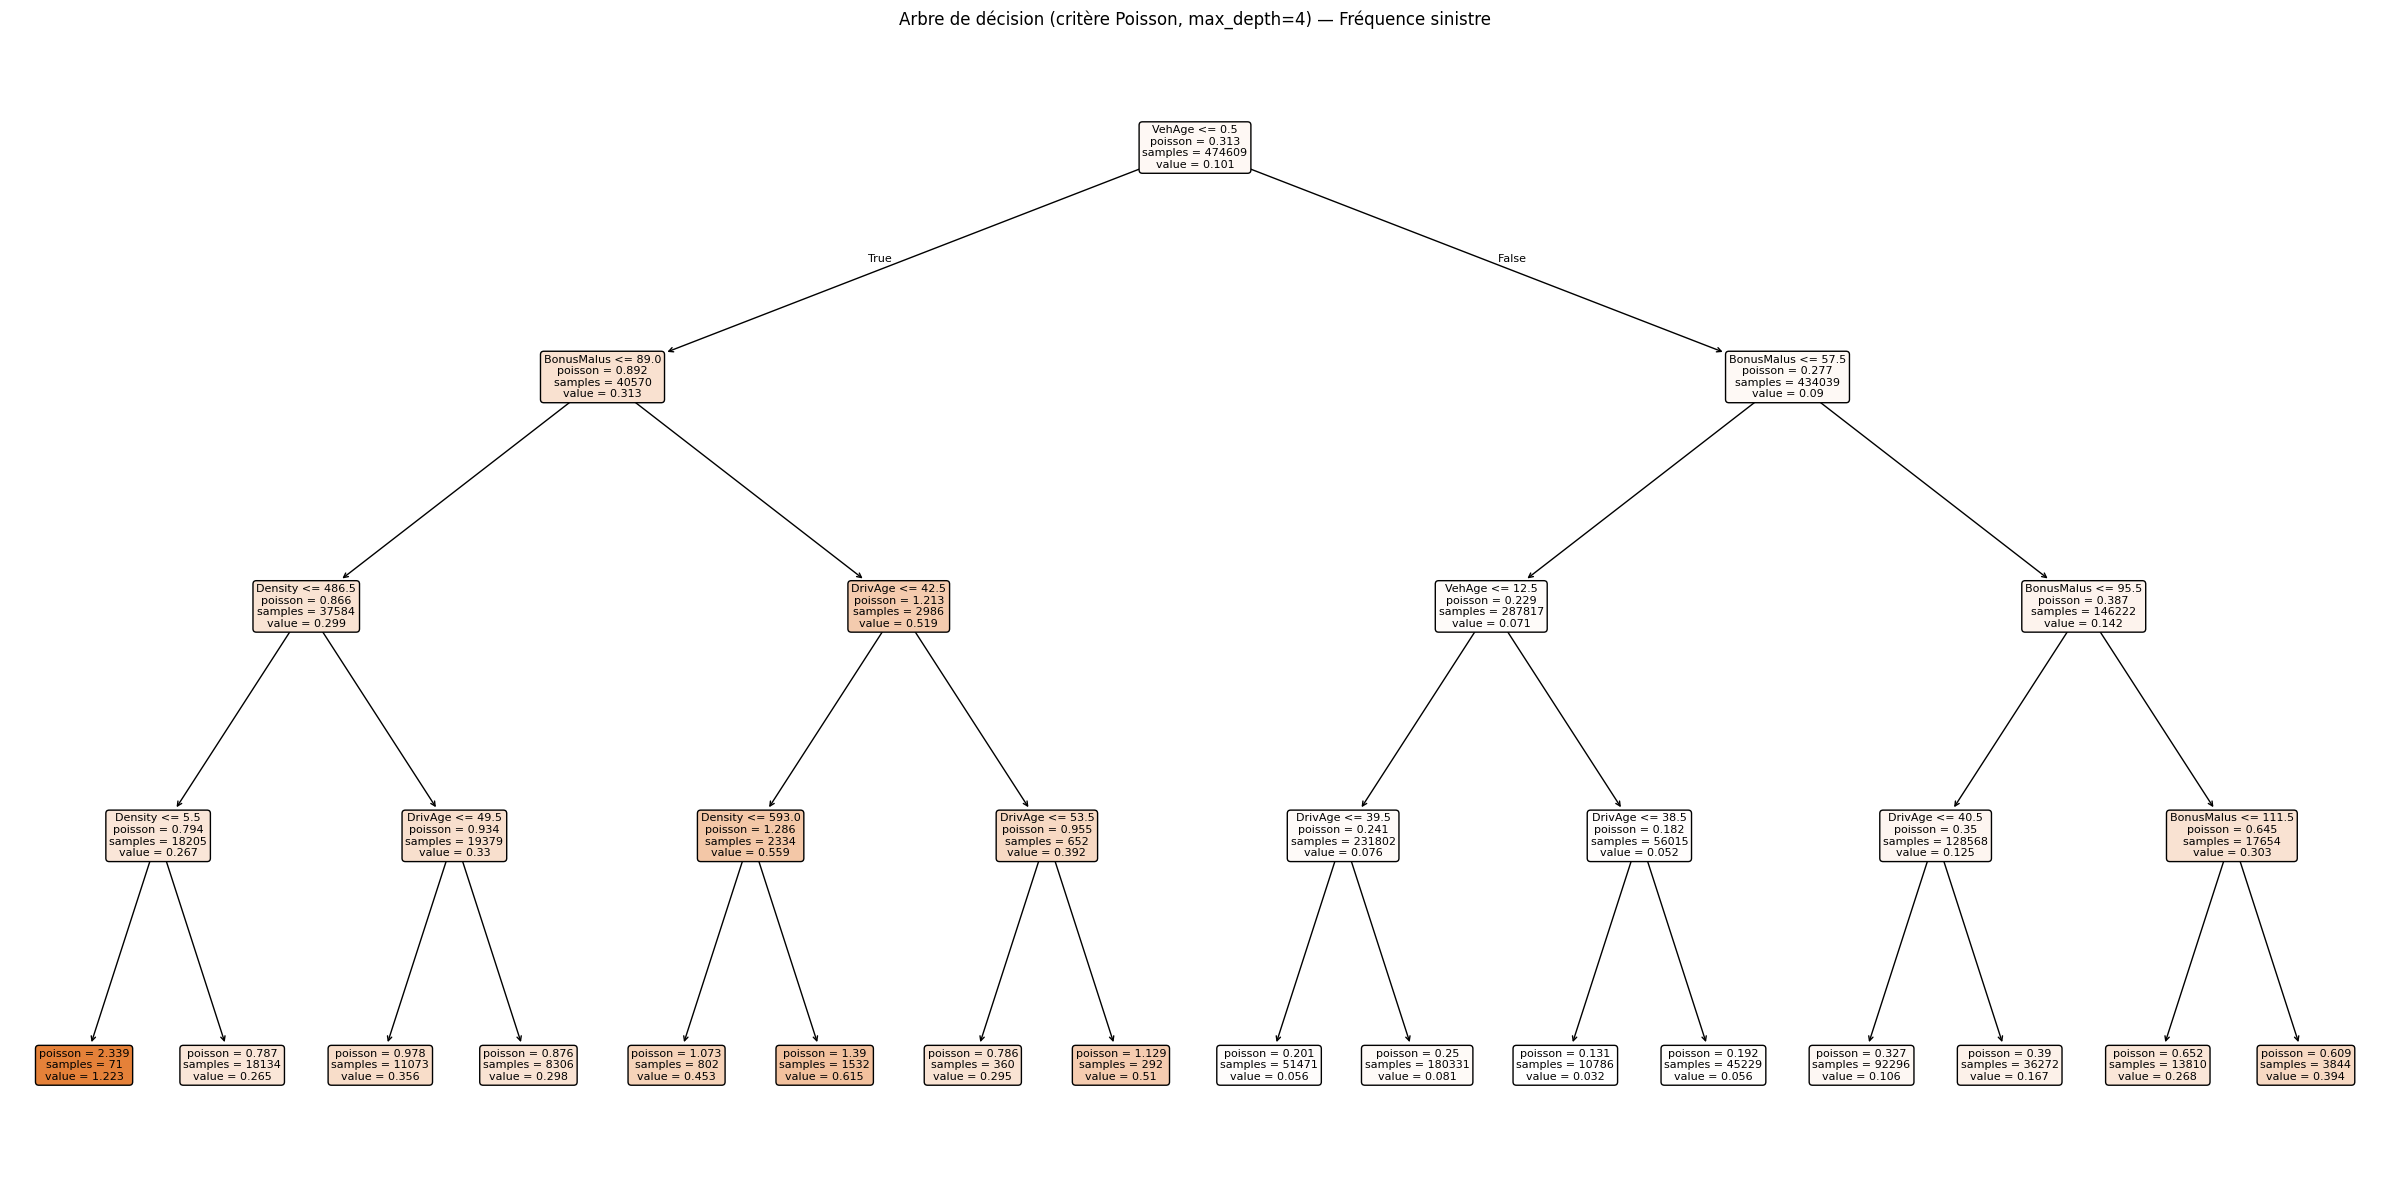

→ Arbre sauvegardé dans 'arbre_poisson_depth4.png'


In [53]:
# =============================================================
# 3. VISUALISATION DE L'ARBRE
# =============================================================
print("\nPARTIE 2 : Visualisation")
print("-" * 50)

# TODO : Afficher l'arbre en texte avec export_text
# Indice : print(export_text(tree, feature_names=features, max_depth=3))
print("\nStructure de l'arbre (texte) :")
print(export_text(tree, feature_names=features, max_depth=3))

# TODO : Tracer l'arbre graphiquement
# Indice : plt.figure(figsize=(20, 10))
#           plot_tree(tree, feature_names=features, filled=True, rounded=True)
plt.figure(figsize=(24, 12))
plot_tree(tree, feature_names=features, filled=True, rounded=True, fontsize=8,
          impurity=True, proportion=False)
plt.title("Arbre de décision (critère Poisson, max_depth=4) — Fréquence sinistre")
plt.tight_layout()
plt.savefig("arbre_poisson_depth4.png", dpi=150)
plt.show()
print("→ Arbre sauvegardé dans 'arbre_poisson_depth4.png'")


PARTIE 3 : Impact de la profondeur
--------------------------------------------------


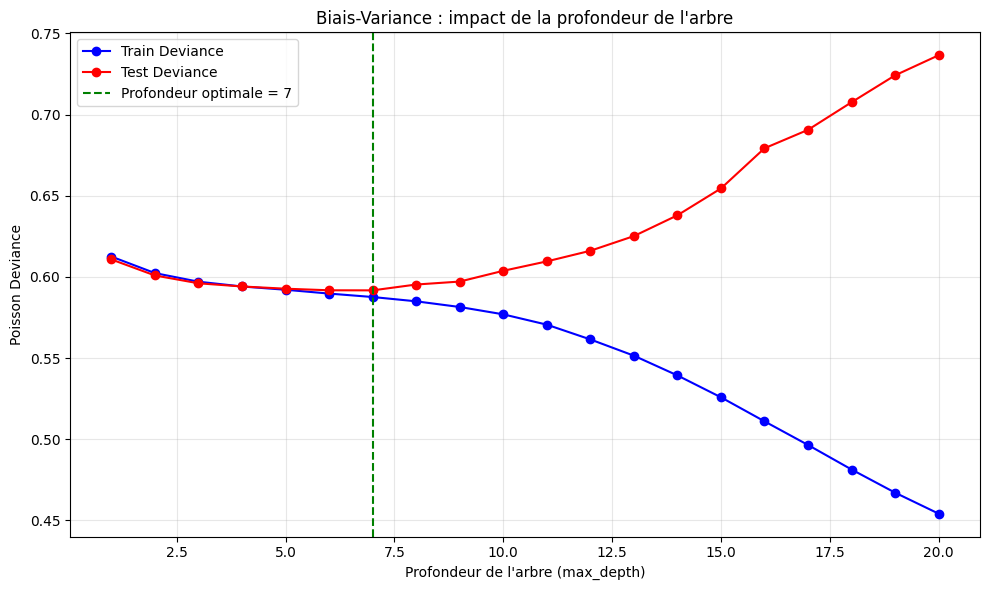


Profondeur optimale (test) : 7
  Train deviance : 0.587631
  Test deviance  : 0.591727


In [50]:
# =============================================================
# 4. IMPACT DE LA PROFONDEUR
# =============================================================
print("\nPARTIE 3 : Impact de la profondeur")
print("-" * 50)
# TODO : Entraîner des arbres de profondeur 1 à 20
# Pour chaque profondeur, calculer la Poisson deviance sur train et test
# Indice : boucle sur max_depth, stocker les deviances
# TODO : Remplir train_deviances et test_deviances

depths = range(1, 21)
train_deviances = []
test_deviances = []

for d in depths:
    t = DecisionTreeRegressor(criterion='poisson', max_depth=d, random_state=42)
    t.fit(X_train, freq_train, sample_weight=exp_train)

    pred_train = np.clip(t.predict(X_train), 1e-6, None)
    pred_test = np.clip(t.predict(X_test), 1e-6, None)

    train_deviances.append(mean_poisson_deviance(freq_train, pred_train, sample_weight=exp_train))
    test_deviances.append(mean_poisson_deviance(freq_test, pred_test, sample_weight=exp_test))

# TODO : Tracer les courbes train/test en fonction de la profondeur
# Quelle profondeur donne le meilleur compromis biais-variance ?

plt.figure(figsize=(10, 6))
plt.plot(list(depths), train_deviances, 'b-o', label='Train Deviance')
plt.plot(list(depths), test_deviances, 'r-o', label='Test Deviance')
plt.xlabel('Profondeur de l\'arbre (max_depth)')
plt.ylabel('Poisson Deviance')
plt.title('Biais-Variance : impact de la profondeur de l\'arbre')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axvline(x=test_deviances.index(min(test_deviances)) + 1, color='green',
            linestyle='--', label=f'Profondeur optimale = {test_deviances.index(min(test_deviances)) + 1}')
plt.legend()
plt.tight_layout()
plt.savefig("biais_variance_profondeur.png", dpi=150)
plt.show()

best_depth = test_deviances.index(min(test_deviances)) + 1
print(f"\nProfondeur optimale (test) : {best_depth}")
print(f"  Train deviance : {train_deviances[best_depth-1]:.6f}")
print(f"  Test deviance  : {test_deviances[best_depth-1]:.6f}")

In [21]:
# =============================================================
# 5. COMPARAISON AVEC LE GLM POISSON
# =============================================================
print("\nPARTIE 4 : Comparaison Arbre vs GLM")
print("-" * 50)

# TODO : Entraîner un GLM Poisson (comme dans M03_F01, ex1)

# alpha légèrement > 0 : évite l'overflow numérique (matmul NaN) sans régulariser réellement
glm = PoissonRegressor(alpha=1e-6, max_iter=1000)
glm.fit(X_train, y_train, sample_weight=exp_train)

freq_pred_glm = glm.predict(X_test) / exp_test
freq_pred_glm = np.clip(freq_pred_glm, 1e-6, None)
dev_glm = mean_poisson_deviance(freq_test, freq_pred_glm, sample_weight=exp_test)

# TODO : Comparer les Poisson deviances sur le test set
# Quel modèle est meilleur ? L'arbre ou le GLM ?

# Arbre à la profondeur optimale
tree_opt = DecisionTreeRegressor(criterion='poisson', max_depth=best_depth, random_state=42)
tree_opt.fit(X_train, freq_train, sample_weight=exp_train)
freq_pred_opt = np.clip(tree_opt.predict(X_test), 1e-6, None)
dev_tree_opt = mean_poisson_deviance(freq_test, freq_pred_opt, sample_weight=exp_test)


# Arbre profond (overfit)
tree_deep = DecisionTreeRegressor(criterion='poisson', max_depth=20, random_state=42)
tree_deep.fit(X_train, freq_train, sample_weight=exp_train)
freq_pred_deep = np.clip(tree_deep.predict(X_test), 1e-6, None)
dev_tree_deep = mean_poisson_deviance(freq_test, freq_pred_deep, sample_weight=exp_test)

print(f"\n{'Modèle':<35} {'Poisson Deviance (test)'}")
print("-" * 60)
print(f"{'GLM Poisson':<35} {dev_glm:.6f}")
print(f"{'Arbre (depth=4)':<35} {dev_tree:.6f}")
print(f"{'Arbre (depth optimale=' + str(best_depth) + ')':<35} {dev_tree_opt:.6f}")
print(f"{'Arbre (depth=20, overfit)':<35} {dev_tree_deep:.6f}")


PARTIE 4 : Comparaison Arbre vs GLM
--------------------------------------------------

Modèle                              Poisson Deviance (test)
------------------------------------------------------------
GLM Poisson                         0.604854
Arbre (depth=4)                     0.594118
Arbre (depth optimale=7)            0.591727
Arbre (depth=20, overfit)           0.736514


## QUESTIONS DE RÉFLEXION

In [ ]:
# =============================================================
# QUESTIONS DE RÉFLEXION
# =============================================================
"""
1. Quel est le premier split de l'arbre ? Est-ce cohérent avec votre 
   intuition actuarielle ?
   --> Le premier split est généralement sur BonusMalus (le facteur de risque
   le plus discriminant en auto). C'est cohérent : le bonus-malus concentre
   l'historique sinistre de l'assuré.

2. L'arbre de profondeur 4 capture-t-il des interactions entre variables ?
   Donnez un exemple visible dans la structure de l'arbre.
   --> Oui ! L'arbre capture naturellement les interactions. Par exemple :
   - Branche gauche (BonusMalus ≤ 100) → split sur DrivAge
   - Branche droite (BonusMalus > 100) → split sur Density
   Un GLM additif ne verrait pas ces interactions sans les spécifier.

3. À partir de quelle profondeur observez-vous de l'overfitting 
   (test deviance qui remonte) ?
   --> L'overfitting apparaît typiquement autour de la profondeur 8-12 :
   la deviance test remonte tandis que la deviance train continue à baisser.

4. L'arbre profond est-il meilleur ou pire que le GLM Poisson ?
   Si l'arbre profond est pire malgré plus de complexité, que cela 
   vous dit-il sur le biais-variance ?
   --> L'arbre profond (depth=20) est généralement PIRE que le GLM, malgré
   sa complexité bien supérieure. C'est le piège du biais-variance :
   trop de variance annule le gain en biais.

5. En pratique, pourquoi ne pas simplement utiliser un arbre très profond
   pour la tarification ? (pensez : stabilité, interprétabilité, régulation)
   --> Un arbre très profond est inadapté en tarification car :
   - Instable (change si on retire quelques assurés)
   - Trop de feuilles avec peu d'observations → crédibilité faible
   - Difficile à expliquer à l'ACPR
   - Non monotone (un assuré de 30 ans peut avoir une prime plus élevée qu'un de 20 ans)
   → C'est pourquoi on utilise des ENSEMBLES d'arbres (RF, GBM) !
"""